In [2]:
from ultralytics import YOLO
from inference import get_model
import numpy as np
import cv2
import matplotlib.pyplot as plt
from coordinate_utils import tile_pixel_to_latlng
from ship import Ship   
import tile_utils
import model_utils

model_utils.load_models()

[10/03/25 10:39:20] WARNING  Your inference package version 0.55.0 is out of date! Please upgrade to ]8;id=215823;file://C:\Users\capet\AppData\Roaming\Python\Python311\site-packages\inference\core\__init__.py\__init__.py]8;;\:]8;id=214565;file://C:\Users\capet\AppData\Roaming\Python\Python311\site-packages\inference\core\__init__.py#41\41]8;;\
                             version 0.58.1 of inference for the latest features and bug fixes by                  
                             running `pip install --upgrade inference`.                                            

Models loaded successfully


Tile 16_18863_25517.webp exists in cache
Running prediction...
[     614.75      170.31      50.492      118.47     0.71282     0.71282]


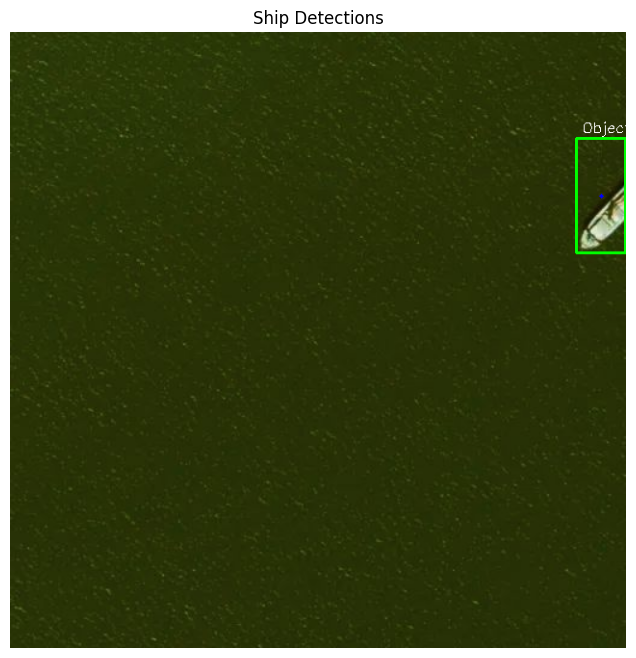

Tile 16_18864_25517.webp exists in cache
Running prediction...
[     30.951      166.96      61.664      113.24     0.78437     0.78437]


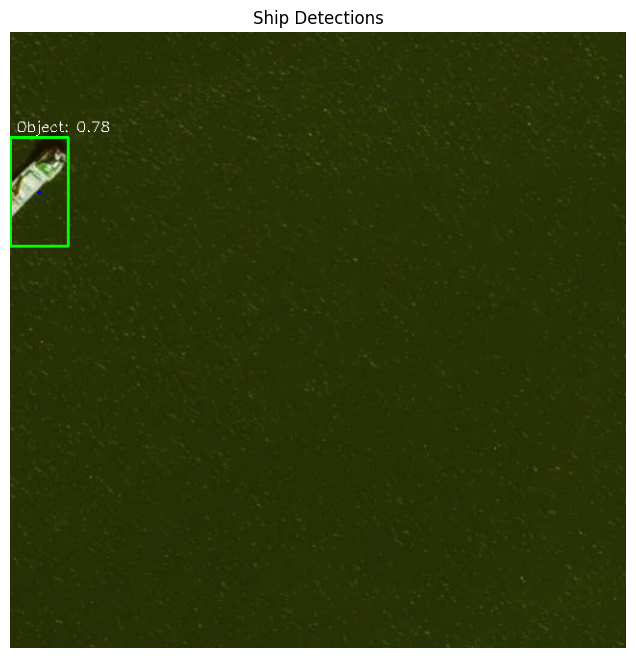

In [3]:


TILE_EXTENSION = "webp"
TILE_FOLDER = "tiles"


def test(tile_tuple):
    z, x, y = tile_tuple
    file_name = f"{z}_{x}_{y}.{TILE_EXTENSION}"
    file_path = TILE_FOLDER + "/" + file_name
    tile_utils.fetch_tile(z, x, y, TILE_FOLDER)
    image = tile_utils.load_tile_image(file_path)
    image_resized = cv2.resize(image, (640, 640))

    # plt.imshow(image)

    predictions = model_utils.detect_ships_in_image(image)

    # predictions = np.squeeze(predictions[0])  # Shape: (8400, 6)

    for box in predictions:
        print(box)

    for box in predictions:
        x_center, y_center, w, h, object_score, class_score = box
    
        # Convert center coordinates to corner coordinates
        x_center = int(x_center)
        y_center = int(y_center)
        x1 = int(x_center - w / 2)
        y1 = int(y_center - h / 2)
        x2 = int(x_center + w / 2)
        y2 = int(y_center + h / 2)
    
        # Draw bounding box
        cv2.rectangle(image_resized, (x1, y1), (x2, y2), (0, 255, 0), 2)
    
        # Draw center point
        cv2.circle(image_resized, (x_center, y_center), radius=2, color=(255, 0, 0), thickness=-1)
    
        # Add confidence score
        cv2.putText(image_resized, f"Object: {object_score:.2f}", (x1 + 6, y1 - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        

    # for i, box in enumerate(predictions):
    #     x_center, y_center, w, h, object_score, class_score = box
    
    #     # Convert to corner coordinates
    #     x1 = int(x_center - w / 2)
    #     y1 = int(y_center - h / 2)
    #     x2 = int(x_center + w / 2)
    #     y2 = int(y_center + h / 2)
    
    #     # Ensure coordinates are within image bounds
    #     x1 = max(0, x1)
    #     y1 = max(0, y1)
    #     x2 = min(image_resized.shape[1], x2)
    #     y2 = min(image_resized.shape[0], y2)
    
    #     # Crop the detected ship
    #     ship_crop = image_resized[y1:y2, x1:x2]
    
    #     # Resize to classification model input size (e.g., 224×224)
    #     ship_resized = cv2.resize(ship_crop, (224, 224))
    #     ship_input = ship_resized.astype("float32") / 255.0
    #     ship_input = np.transpose(ship_input, (2, 0, 1))  # [C, H, W]
    #     ship_input = np.expand_dims(ship_input, axis=0)   # [1, C, H, W]
    
    #     # Run classification
    #     class_result = classification_model.predict(ship_input)
    #     class_probs = np.squeeze(class_result[0])
    #     class_id = int(np.argmax(class_probs))
    #     class_conf = float(class_probs[class_id])
    #     class_name = classification_model.class_names[class_id]
    
    #     # Display classification result
    #     label = f"Type: {class_name} ({class_conf:.2f})"
    #     cv2.putText(image_resized, label, (x1 + 6, y2 + 16),
    #                 cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)


    # Convert BGR (OpenCV format) to RGB for correct display
    image_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)
    
    # Display using matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(image_rgb)
    plt.axis('off')  # Hide axes
    plt.title("Ship Detections")
    plt.show()       
    

z, x, y = 16, 18863, 25517
test((z, x, y))
z, x, y = 16, 18864, 25517
test((z, x, y))
# z, x, y = z-1, x//2, y//2
# test((z, x, y))
# z, x, y = z-1, x//2, y//2
# test((z, x, y))
# z, x, y = z-1, x//2, y//2
# test((z, x, y))
     
# test((10, 10, 10))

In [50]:
labels = classification_model.class_names
print("Class labels:", labels)



Class labels: ['Aircraft Carrier', 'Auxiliary Ship', 'Barge', 'Cargo', 'Commander', 'Container Ship', 'Cruiser', 'Destroyer', 'Dock', 'Ferry', 'Fishing Vessel', 'Frigate', 'Hovercraft', 'Landing', 'Motorboat', 'Oil Tanker', 'Other Merchant', 'Other Ship', 'Other Warship', 'Patrol', 'RoRo', 'Sailboat', 'Submarine', 'Tugboat', 'Yacht']
